
Tree height: 5.865073
Tree length: 12.248029
strictly bifurcating tree
annotations present

Numbers of objects in tree: 101 (50 nodes and 51 leaves)



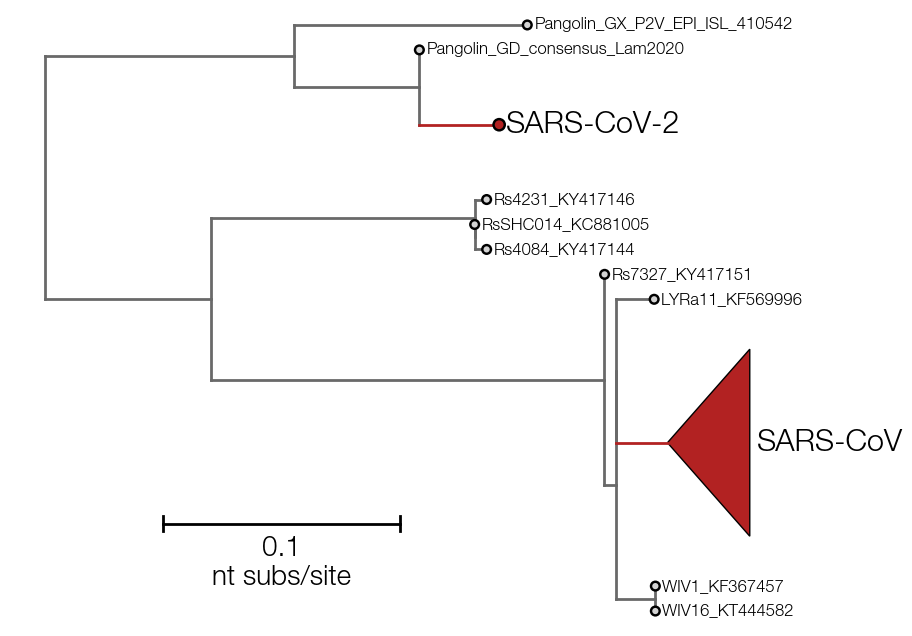

In [1]:
#########
## data taken from: 
## Starr, T.N., Zepeda, S.K., Walls, A.C. et al. 
## ACE2 binding is an ancestral and evolvable trait of sarbecoviruses. 
## Nature 603, 913–918 (2022). 
## https://doi.org/10.1038/s41586-022-04464-z
## https://github.com/jbloomlab/SARSr-CoV_homolog_survey/blob/52db008d423a17d622950d6311fd89392cdc5e1d/RBD_ASR/RBD_rm_RaTG13/ASR/tree.newick.txt
#########

import os

import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

import baltic as bt

basePath = '/mnt/c/Users/evogytis/repos/baltic-v1-manuscript/'

ll = bt.io.load_newick(os.path.join(basePath, 'data/Fig2_reroot-collapse-pad/tree.newick.txt'), 'divergence') ## load tree

ll.treeStats()

######### rename SARS-CoV-2
for k in ll.get_external():
    if k.name == 'SARS_CoV_2_MN908947':
        k.name = 'SARS-CoV-2'
###
get_sarscov1 = lambda k: k.is_leaflike() and ('SARS_CoV_1_' in k.name or k.name == 'SARS-CoV')
get_sarscov2 = lambda k: k.is_leaflike() and k.name == 'SARS-CoV-2'

ll = ll.subtree(ll.find_MRCA([k for k in ll.Objects if get_sarscov1(k) or get_sarscov2(k)]), stem=False) ## extract subtree from which both SARS coronaviruses are descended
ll.reroot() ## midpoint root

ll = ll.subtree(ll.find_MRCA([k for k in ll.Objects if get_sarscov1(k) or get_sarscov2(k)]), stem=False) ## further subset to descendant subtree

#######
sarscov1 = ll.find_MRCA(ll.get_external(lambda k: 'SARS_CoV_1_' in k.name)) ## find TMRCA of all tips that have "SARS_CoV_1_" in their name

ll.collapse_subtree_to_clade(sarscov1, 'SARS-CoV', widthFunction=lambda k: len(k.leaves) / 2) ## collapse SARS-CoV subtree

###########

fig = plt.figure(figsize=(10, 8), facecolor='w')
gs = GridSpec(1, 1, hspace=0.01, wspace=0.05)

ax = plt.subplot(gs[0], zorder=1000, facecolor='w')
####

sarscov1 = ll.get_external(get_sarscov1, onlyLeaves=False)[0] ## grabbing a clade object here, onlyLeaves must be False
sarscov2 = ll.get_external(get_sarscov2)[0]
padNodes = {sarscov1: 1, sarscov2: 2} ## set up custom padding around branches
####

ll.plot_tree(ax, targetFxn=lambda k: not get_sarscov1(k) and not get_sarscov2(k), padNodes=padNodes, colour='dimgray', zorder=1) ## gray branches
ll.plot_tree(ax, targetFxn=lambda k: get_sarscov1(k) or get_sarscov2(k), padNodes=padNodes, colour='firebrick', cladeColour='firebrick', cladeStyle='equal', zorder=1) ## overlay branches leading to SARS coronaviruses in red

ll.plot_points(ax, colour='lightgray', pointSize=20, padNodes=padNodes) ## gray tip circles
ll.plot_points(ax, targetFxn=get_sarscov2, colour='firebrick', padNodes=padNodes) ## red circle for SARS-CoV-2

ll.plot_text(ax, xCoordinateFxn=lambda k: k.height + 0.003, targetFxn=lambda k: k.is_leaflike() and (not get_sarscov1(k) and not get_sarscov2(k)), size=12, padNodes=padNodes) ## add tip labels

ll.plot_text(ax, xCoordinateFxn=lambda k: k.lastHeight + 0.003, targetFxn=get_sarscov1, size=22, padNodes=padNodes) ## text label for SARS-CoV
ll.plot_text(ax, xCoordinateFxn=lambda k: k.height + 0.003, targetFxn=get_sarscov2, size=22, padNodes=padNodes) ## text label for SARS-CoV-2

########
bt.bt_utils.plot_scale_bar(ax=ax, tree=ll, xy=(0.05, 4), unitText='nt subs/site', style='fancy', fancyWidth=3, textKwargs={'size': 20}) ## scale bar
############
ax.set_ylim(-0.1, ll.ySpan + 0.1)

bt.bt_utils.clean_axes(ax)
####
plt.savefig(os.path.join(basePath, 'figures/Fig2_reroot-collapse-pad.png'), bbox_inches='tight', dpi=300)
plt.savefig(os.path.join(basePath, 'figures/Fig2_reroot-collapse-pad.pdf'), bbox_inches='tight', dpi=300)
plt.show()